# JEPA world model — checkpoint evaluation

Plug checkpoints into the `MODELS` / `EVALS` config below, run all cells, and
get a readable picture of **what the model learned and what it didn't**. Runs
entirely from the cached DINOv2 embeddings — no backbone download needed.

The battery, roughly in order of "is anything alive" → "is it useful":

| § | Question it answers |
|---|---|
| 1. Training curves | Did training behave (no collapse, loss actually descending)? |
| 2. Latent geometry | Is the latent space non-degenerate (spread, effective rank)? |
| 3. Latent maps | Does the latent organize by place / heading / action at all? |
| 4. Linear probes | Is physical state (position, heading, action) *decodable* from the latent? |
| 5. One-step prediction | Does the predictor beat the copy-machine baseline? |
| 6. Multi-step rollouts | How fast do open-loop predictions diverge? |
| 7. Loop closure | Does a returning trajectory / a 360° spin return in latent space? |
| 8. Planning | Can searching the predictor's imagination recover sensible actions? |
| 9. Verdict | Auto-generated ✅/⚠️/❌ summary per model. |

Evaluation practice follows the JEPA / latent-world-model literature: linear
probing as the standard representation-quality measure, effective-rank-style
collapse metrics, open-loop rollout divergence over horizon, action/cycle
consistency, and goal-conditioned planning in latent space (references at the
bottom).

In [1]:
import itertools
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

from vsa_cognitive_mapping.data import ACTIONS, CachedTransitionDataset, load_pose_by_frame
from vsa_cognitive_mapping.diagnostics import collapse_metrics
from vsa_cognitive_mapping.model import JEPAWorldModel

ROOT = Path("..").resolve()

# ---- plug your checkpoints in here -----------------------------------------
MODELS = {
    "scand":     dict(config="configs/jepa_scand.yaml",        checkpoint="checkpoints/jepa_scand/final.pt"),
    "finetuned": dict(config="configs/jepa_run1_ft.yaml",      checkpoint="checkpoints/jepa_run1_ft/final.pt"),
    "scratch":   dict(config="configs/jepa_run1_scratch.yaml", checkpoint="checkpoints/jepa_run1_scratch/final.pt"),
}
# (model, dataset root, val_fraction, label) — evaluated on the val split
EVALS = [
    ("scand",     "data/scand_indoor", 0.15, "scand → SAC held-out"),
    ("scand",     "data/spot_run1",    0.7,  "zero-shot → run1"),
    ("finetuned", "data/spot_run1",    0.7,  "finetuned → run1"),
    ("scratch",   "data/spot_run1",    0.7,  "scratch → run1"),
]
# -----------------------------------------------------------------------------

BLUE, AQUA, YELLOW, GREEN, VIOLET, MUTED, GRID = ("#2a78d6", "#1baf7a", "#eda100",
                                                  "#008300", "#4a3aa7", "#898781", "#e1e0d9")
MODEL_COLORS = {"scand": BLUE, "finetuned": AQUA, "scratch": YELLOW}
EVAL_COLORS = {"scand → SAC held-out": BLUE, "zero-shot → run1": VIOLET,
               "finetuned → run1": AQUA, "scratch → run1": YELLOW}
ACTION_COLORS = dict(zip(ACTIONS, (BLUE, AQUA, YELLOW, GREEN)))
plt.rcParams.update({"axes.edgecolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
                     "figure.dpi": 90})


def load_model(name):
    spec = MODELS[name]
    cfg = yaml.safe_load(open(ROOT / spec["config"]))
    model = JEPAWorldModel.from_config(cfg["model"])
    state = torch.load(ROOT / spec["checkpoint"], map_location="cpu")
    model.load_state_dict(state["model"] if "model" in state else state)
    return model.eval(), cfg


@torch.no_grad()
def load_run(model_name, root, val_fraction, split="val"):
    """Encode one (model, dataset-split) pair; everything downstream reads this."""
    model, cfg = load_model(model_name)
    root = ROOT / root
    cache = torch.load(root / "embeddings_dinov2_vits14.pt")
    ds = CachedTransitionDataset(root, cache, split=split, val_fraction=val_fraction)
    pose = load_pose_by_frame(root)
    ft, ftp1 = ds.df["frame_t"].to_numpy(), ds.df["frame_tp1"].to_numpy()
    breaks = np.flatnonzero(ftp1[:-1] != ft[1:]) + 1  # bag/episode boundaries
    return dict(
        model=model, ds=ds, emb_t=ds.emb_t, emb_tp1=ds.emb_tp1,
        z_t=model.encode(ds.emb_t), z_tp1=model.encode(ds.emb_tp1),
        z_pred=model.predictor(model.encode(ds.emb_t), ds.actions),
        act=ds.actions.argmax(1).numpy(),
        pos=np.array([pose[int(f)][:2] for f in ft]),
        yaw=np.array([pose[int(f)][3] for f in ft]),
        segs=np.split(np.arange(len(ds)), breaks),
    )


runs = {}
for m, root, vf, label in EVALS:
    if not (ROOT / MODELS[m]["checkpoint"]).exists():
        print(f"skipping {label}: no checkpoint at {MODELS[m]['checkpoint']}")
        continue
    runs[label] = load_run(m, root, vf)
    r = runs[label]
    print(f"{label}: {len(r['z_t'])} transitions, {len(r['segs'])} contiguous segment(s)")

scand → SAC held-out: 847 transitions, 2 contiguous segment(s)
zero-shot → run1: 138 transitions, 1 contiguous segment(s)
finetuned → run1: 138 transitions, 1 contiguous segment(s)
scratch → run1: 138 transitions, 1 contiguous segment(s)


## 1. Training curves — did training behave?

Read from each run's `metrics.csv`. What healthy LeJEPA training looks like
(distilled from the topjepa lessons):

- **`mse` descends gradually** and never pins at ~0 in the first epoch — an
  instantly-zero MSE means the latents collapsed to a constant, which makes
  prediction trivially perfect and useless.
- **`sigreg` stays positive.** It is a statistical test pushing latents toward
  an isotropic Gaussian; if it goes negative something is optimizing the
  regularizer itself (a known failure mode when quadrature constants leak
  into the parameter tree).
- **`per_dim_std` ≈ 1** (BatchNorm should enforce this on train batches) and
  **effective rank well above 1**: the number of latent dimensions actually
  in use. 128-dim latents with rank ~15 use only a small subspace — not
  ideal, but rank *decaying toward 1* is the collapse signature.

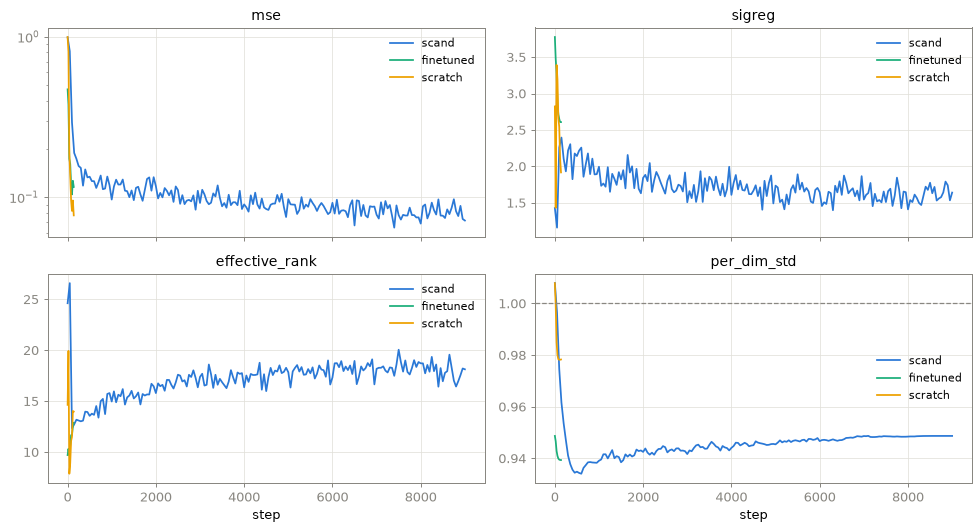

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
panels = [("mse", axes[0, 0], "log"), ("sigreg", axes[0, 1], "linear"),
          ("effective_rank", axes[1, 0], "linear"), ("per_dim_std", axes[1, 1], "linear")]
for name in MODELS:
    _, cfg = load_model(name)
    mpath = ROOT / cfg["train"]["out_dir"] / "metrics.csv"
    if not mpath.exists():
        continue
    hist = pd.read_csv(mpath)
    for col, ax, scale in panels:
        ax.plot(hist["step"], hist[col], color=MODEL_COLORS[name], lw=1.4, label=name)
        ax.set_title(col, fontsize=11)
        ax.set_yscale(scale)
for _, ax, _ in panels:
    ax.legend(frameon=False, fontsize=9)
axes[1, 0].set_xlabel("step"); axes[1, 1].set_xlabel("step")
axes[1, 1].axhline(1.0, color=MUTED, ls="--", lw=1)
plt.tight_layout()

## 2. Latent geometry — is the space degenerate?

The eigenspectrum of the latent covariance tells you how many directions carry
variance. A healthy spectrum decays smoothly; a cliff after a few components
means the latent is effectively low-dimensional. **Effective rank**
(exp of the spectrum's entropy — the idea behind RankMe) compresses this to
one number; higher = richer representation. We compute it on *evaluation*
data, so unlike the training curves this also reflects distribution shift:
a model whose BatchNorm statistics don't fit the eval domain will show
off-center, low-spread latents here even if training looked perfect.

,per_dim_std,effective_rank,mean_pairwise_cosine
eval,,,
scand → SAC held-out,0.683,17.328,0.242
zero-shot → run1,0.653,8.536,0.601
finetuned → run1,1.443,8.498,0.208
scratch → run1,1.163,11.529,0.277


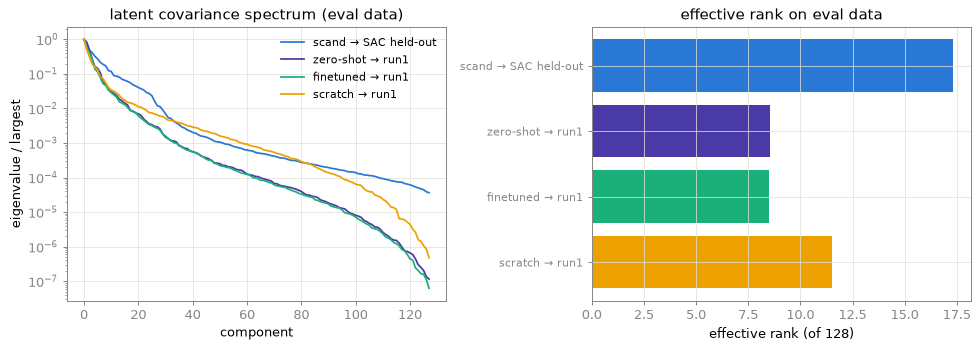

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
rows = []
for label, r in runs.items():
    z = torch.cat([r["z_t"], r["z_tp1"]])
    lam = torch.linalg.eigvalsh(torch.cov(z.T)).flip(0).clamp(min=1e-12)
    ax1.semilogy(lam / lam[0], color=EVAL_COLORS[label], lw=1.4, label=label)
    rows.append({"eval": label, **{k: round(v, 3) for k, v in collapse_metrics(z).items()}})
ax1.set_xlabel("component"); ax1.set_ylabel("eigenvalue / largest")
ax1.set_title("latent covariance spectrum (eval data)")
ax1.legend(frameon=False, fontsize=9)

stats = pd.DataFrame(rows).set_index("eval")
ax2.barh(np.arange(len(stats)), stats["effective_rank"],
         color=[EVAL_COLORS[l] for l in stats.index])
ax2.set_yticks(np.arange(len(stats)), stats.index, fontsize=9)
ax2.set_xlabel("effective rank (of 128)")
ax2.set_title("effective rank on eval data")
ax2.invert_yaxis()
plt.tight_layout()
stats

## 3. Latent maps — what does the space organize by?

2-D PCA of the eval latents along the trajectory. Each column colors the same
points by a different ground-truth variable:

- **time**: a trajectory that traces a coherent path in latent space (rather
  than a shapeless blob) means consecutive observations stay close — the
  minimum for a usable world model.
- **heading (yaw)**: color bands = the latent encodes which way the robot
  faces. Expected to be strong: an egocentric camera's view is dominated by
  heading.
- **action**: turns living in specific regions would mean the *encoder* sees
  motion; usually action effects live in latent *differences* (§4), not
  positions, so a mixed picture here is normal.

This is qualitative on purpose — §4 quantifies the same questions.

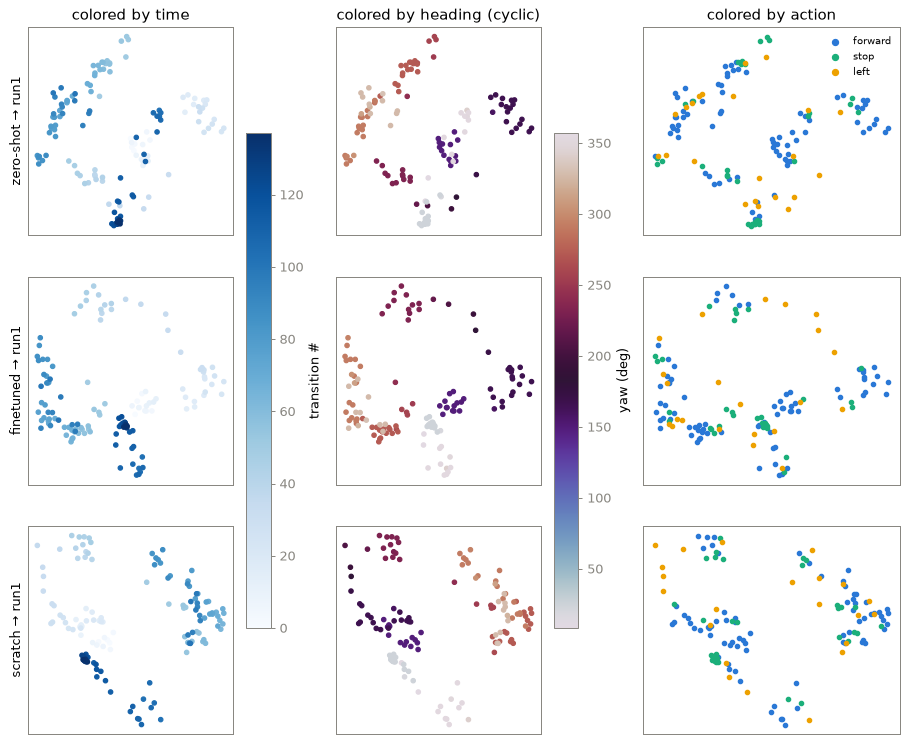

In [4]:
run1_labels = [l for l in runs if "run1" in l]
fig, axes = plt.subplots(len(run1_labels), 3, figsize=(12.5, 3.4 * len(run1_labels)),
                         squeeze=False)
for i, label in enumerate(run1_labels):
    r = runs[label]
    z = r["z_t"]
    zc = z - z.mean(0)
    _, _, V = torch.pca_lowrank(zc, q=2)
    p = (zc @ V[:, :2]).numpy()
    t = np.arange(len(p))
    sc0 = axes[i, 0].scatter(p[:, 0], p[:, 1], c=t, cmap="Blues", s=12)
    sc1 = axes[i, 1].scatter(p[:, 0], p[:, 1], c=np.degrees(r["yaw"]) % 360,
                             cmap="twilight", s=12)
    for a, name in enumerate(ACTIONS):
        m = r["act"] == a
        if m.any():
            axes[i, 2].scatter(p[m, 0], p[m, 1], color=ACTION_COLORS[name], s=12, label=name)
    axes[i, 0].set_ylabel(label, fontsize=10)
    for ax in axes[i]:
        ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_title("colored by time")
axes[0, 1].set_title("colored by heading (cyclic)")
axes[0, 2].set_title("colored by action")
axes[0, 2].legend(frameon=False, fontsize=8, markerscale=1.4)
fig.colorbar(sc0, ax=axes[:, 0], shrink=0.7, label="transition #")
fig.colorbar(sc1, ax=axes[:, 1], shrink=0.7, label="yaw (deg)")

## 4. Linear probes — is the latent *informative*?

The standard representation-quality measure in self-supervised learning.
The logic: freeze the representation, train the **smallest possible readout**
(here ridge regression) from latent → a ground-truth variable, and measure
held-out R². If a *linear* map can recover the variable, the representation
exposes it explicitly; a low score means the information is absent or
entangled beyond linear reach. We probe:

- **position (x, y)** from `z` — does the latent function as a *place* code?
- **heading** as (sin yaw, cos yaw) — angles are circular, so probing the raw
  angle would break at the ±180° wrap.
- **action from the latent step `z_{t+1} − z_t`** (an *inverse-dynamics*
  probe): can you tell what the robot did from how the latent moved? This is
  precisely what the predictor needs to be learnable.

Two disciplines worth copying:

- **The split must respect time, but also cover space.** A random split leaks
  (adjacent frames are near-duplicates → inflated R²); a single contiguous
  split forces spatial *extrapolation* (the test chunk visits places the
  train chunk never saw → misleadingly negative R², which is exactly what an
  earlier version of this notebook produced). The compromise used here:
  **alternating temporal blocks** — ~10 contiguous chunks, even ones train,
  odd ones test. Leakage is confined to block boundaries and both sets cover
  the workspace.
- Every probe on `z` is compared against the same probe on the **raw DINOv2
  embedding**. The backbone is frozen and generic, so it roughly
  upper-bounds what our trained head *could* pass through; a head scoring
  far below it has *discarded* that information, which no amount of
  predictor training can recover.

One more trap specific to multi-trajectory data: each bag's odometry frame
has an **arbitrary origin**, so position/heading probes are computed within
the largest contiguous segment only — pooling segments would ask the probe
to regress across incompatible coordinate systems.

,pos R² (z),heading R² (z),action acc (Δz),majority
eval,,,,
scand → SAC held-out,0.614,0.742,0.924,0.924
zero-shot → run1,0.897,0.920,0.362,0.536
finetuned → run1,0.905,0.918,0.377,0.536
scratch → run1,0.861,0.922,0.449,0.536
DINOv2 backbone (run1),0.937,0.966,0.391,0.536
DINOv2 backbone (scand),0.628,0.722,0.735,0.924


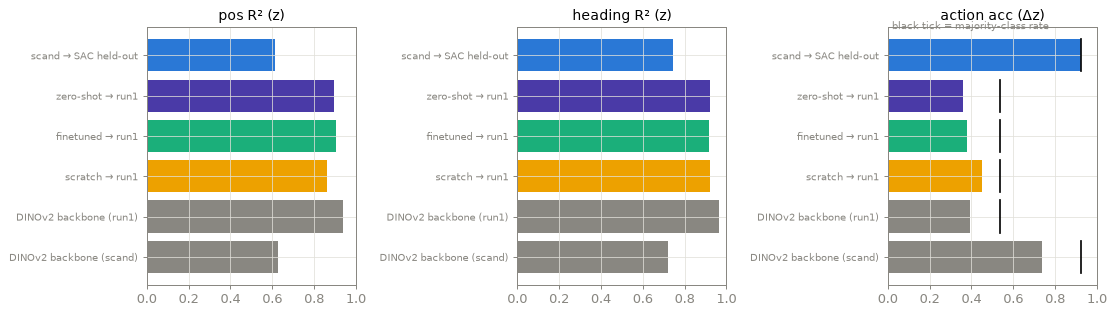

In [5]:
def _fit(X, Y, lam):
    X1 = np.c_[X, np.ones(len(X))]
    return np.linalg.solve(X1.T @ X1 + lam * np.eye(X1.shape[1]), X1.T @ Y)

def _r2(W, X, Y):
    pred = np.c_[X, np.ones(len(X))] @ W
    return 1 - ((Y - pred) ** 2).sum() / ((Y - Y.mean(0)) ** 2).sum()

def blocked_split(n, n_blocks=10):
    """Alternating contiguous blocks: even -> train, odd -> test."""
    blocks = np.array_split(np.arange(n), n_blocks)
    return np.concatenate(blocks[0::2]), np.concatenate(blocks[1::2])

def ridge_probe(X, Y, lams=(0.1, 1.0, 10.0, 100.0, 1e3, 1e4, 1e5)):
    """Best held-out R² over the ridge-strength grid (the usual linear-probe
    protocol: sweep the regularizer, report the best probe)."""
    X, Y = np.asarray(X, dtype=np.float64), np.asarray(Y, dtype=np.float64)
    tr, te = blocked_split(len(X))
    mu, sd = X[tr].mean(0), X[tr].std(0) + 1e-8
    Xs = (X - mu) / sd
    return max(_r2(_fit(Xs[tr], Y[tr], l), Xs[te], Y[te]) for l in lams)

def action_probe(dz, y):
    """Linear one-vs-all readout of the action from the latent step."""
    tr, te = blocked_split(len(dz))
    mu, sd = dz[tr].mean(0), dz[tr].std(0) + 1e-8
    W = _fit((dz[tr] - mu) / sd, np.eye(len(ACTIONS))[y[tr]], 10.0)
    pred = (np.c_[(dz[te] - mu) / sd, np.ones(len(te))] @ W).argmax(1)
    majority = np.bincount(y[te], minlength=4).max() / len(te)
    return (pred == y[te]).mean(), majority

# Probe within the LARGEST contiguous segment only: each bag's odometry frame
# has an arbitrary origin, so pooling segments would mix coordinate systems.
def probe_inputs(r, X_t, X_tp1):
    seg = max(r["segs"], key=len)
    heading = np.c_[np.sin(r["yaw"][seg]), np.cos(r["yaw"][seg])]
    acc, maj = action_probe((X_tp1 - X_t).numpy()[seg], r["act"][seg])
    return {
        "pos R² (z)": ridge_probe(X_t.numpy()[seg], r["pos"][seg]),
        "heading R² (z)": ridge_probe(X_t.numpy()[seg], heading),
        "action acc (Δz)": acc, "majority": maj,
    }

probe_rows = [{"eval": label, **probe_inputs(r, r["z_t"], r["z_tp1"])}
              for label, r in runs.items()]
# backbone baseline once per dataset (identical inputs for every model)
backbone_rows = [{"eval": f"DINOv2 backbone ({'run1' if 'run1' in label else 'scand'})",
                  **probe_inputs(runs[label], runs[label]["emb_t"], runs[label]["emb_tp1"])}
                 for label in ("zero-shot → run1", "scand → SAC held-out") if label in runs]
probes = pd.DataFrame(probe_rows + backbone_rows).set_index("eval").round(3)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
for ax, col in zip(axes, ["pos R² (z)", "heading R² (z)", "action acc (Δz)"]):
    colors = [EVAL_COLORS.get(l, MUTED) for l in probes.index]
    ax.barh(np.arange(len(probes)), probes[col].clip(lower=0), color=colors)
    ax.set_yticks(np.arange(len(probes)), probes.index, fontsize=8)
    ax.set_title(col, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
for i, m in enumerate(probes["majority"]):  # per-eval chance level for the action probe
    axes[2].plot([m, m], [i - 0.4, i + 0.4], color="#0b0b0b", lw=1.4)
axes[2].text(0.02, -0.65, "black tick = majority-class rate", fontsize=8, color=MUTED)
plt.tight_layout()
probes

## 5. One-step prediction — does the predictor beat the copy machine?

`rel-MSE = MSE(predictor) / MSE(z_{t+1} := z_t)`. The **persistence baseline**
(just copy the current latent) is brutal on slow robots: if little changes
between frames, copying is nearly optimal. rel-MSE < 1 is the bar for
"learned action-conditioned dynamics".

The scatter shows every transition: points **below the diagonal** are
transitions where the predictor beat persistence. Per-action patterns matter —
`stop` transitions sit near the origin (persistence is near-perfect there by
definition), so a model only wins by predicting *motion* correctly.

,rel-MSE,rel forward,rel stop,rel left,rel right
eval,,,,,
scand → SAC held-out,1.27,1.32,1.17,1.10,1.09
zero-shot → run1,2.48,2.54,4.94,1.55,NaN
finetuned → run1,2.92,3.23,5.45,1.62,NaN
scratch → run1,4.61,4.65,8.29,2.98,NaN


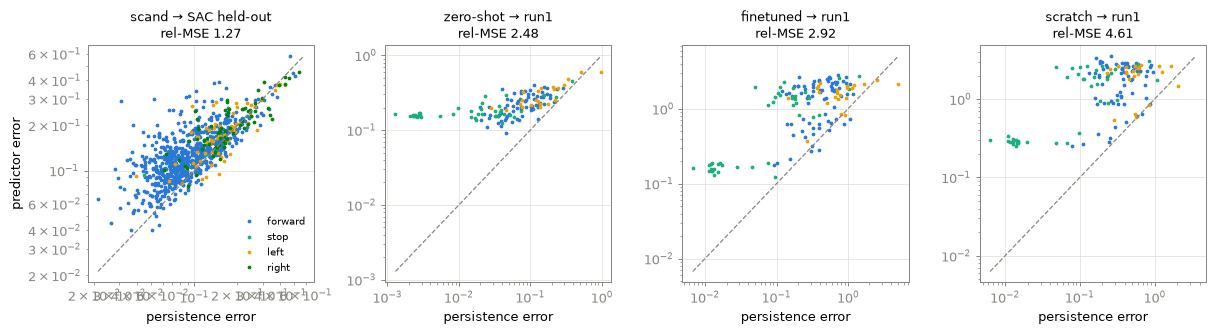

In [6]:
fig, axes = plt.subplots(1, len(runs), figsize=(3.4 * len(runs), 3.8), squeeze=False)
rel_rows = []
for ax, (label, r) in zip(axes[0], runs.items()):
    mse = (r["z_pred"] - r["z_tp1"]).square().mean(1).numpy()
    pers = (r["z_t"] - r["z_tp1"]).square().mean(1).numpy()
    rel_rows.append({"eval": label, "rel-MSE": mse.mean() / pers.mean(),
                     **{f"rel {a}": mse[r['act'] == i].mean() / pers[r['act'] == i].mean()
                        for i, a in enumerate(ACTIONS) if (r['act'] == i).any()}})
    for i, a in enumerate(ACTIONS):
        m = r["act"] == i
        if m.any():
            ax.loglog(pers[m], mse[m], ".", color=ACTION_COLORS[a], ms=4, label=a)
    lims = [min(pers.min(), mse.min()), max(pers.max(), mse.max())]
    ax.plot(lims, lims, color=MUTED, lw=1, ls="--")
    ax.set_title(f"{label}\nrel-MSE {mse.mean()/pers.mean():.2f}", fontsize=10)
    ax.set_xlabel("persistence error")
axes[0, 0].set_ylabel("predictor error")
axes[0, 0].legend(frameon=False, fontsize=8)
plt.tight_layout()
pd.DataFrame(rel_rows).set_index("eval").round(2)

## 6. Multi-step open-loop rollouts — how fast does imagination drift?

Start from a real latent, apply the predictor **autoregressively** with the
recorded action sequence, never re-observing. Plotted: prediction error at
horizon *h*, normalized by the *hold-the-start* baseline (predicting
`z_{t+h} := z_t` — "the world never changes"). Below 1.0 = the rollout is
more informative than standing still; the crossing point is the model's
usable **planning horizon**. Even good single-step models often cross within
a few steps — one-step errors compound exponentially in open loop.

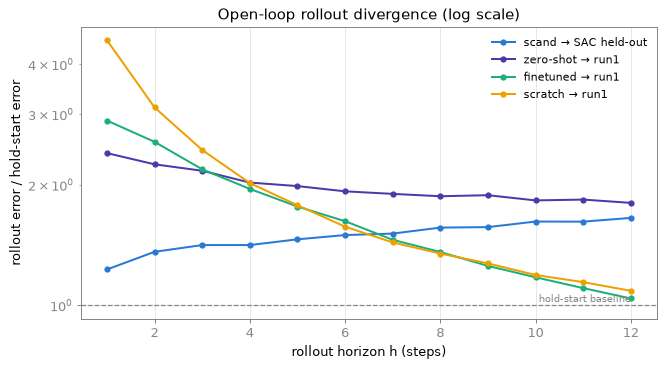

In [7]:
H = 12

@torch.no_grad()
def rollout_curve(r, H):
    err = [[] for _ in range(H)]
    base = [[] for _ in range(H)]
    for seg in r["segs"]:
        if len(seg) < H:
            continue
        for s in range(0, len(seg) - H, 2):
            rows = seg[s:s + H]
            z = r["z_t"][seg[s]][None]
            for h, row in enumerate(rows):
                z = r["model"].predictor(z, r["ds"].actions[row][None])
                err[h].append((z[0] - r["z_tp1"][row]).square().mean().item())
                base[h].append((r["z_t"][seg[s]] - r["z_tp1"][row]).square().mean().item())
    return (np.array([np.mean(e) for e in err]),
            np.array([np.mean(b) for b in base]))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for label, r in runs.items():
    err, base = rollout_curve(r, H)
    ax.plot(np.arange(1, H + 1), err / base, color=EVAL_COLORS[label], lw=1.6,
            marker="o", ms=4, label=label)
ax.axhline(1.0, color=MUTED, ls="--", lw=1)
ax.text(H, 1.02, "hold-start baseline", color=MUTED, fontsize=8, ha="right")
ax.set_xlabel("rollout horizon h (steps)")
ax.set_ylabel("rollout error / hold-start error")
ax.set_title("Open-loop rollout divergence (log scale)")
ax.set_yscale("log")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()

## 7. Loop closure — does coming back look like coming back?

run1 physically returns to its start (0.4 m gap after a 24 m loop), which
gives a free **cycle-consistency** test at two levels:

- **Encoder level** (no predictor): is `z` of the final frame close to `z` of
  the first? This only requires similar views to map to similar latents.
- **Predictor level**: roll the predictor open-loop through *all* recorded
  actions. A dynamics model with consistent action semantics should produce a
  latent trajectory whose distance-to-start correlates with the true
  distance-to-start — including the return dip at the end. Expect failure at
  233 steps with a one-step MLP; the point is *how* it fails.

The synthetic **spin test** removes trajectory noise: from a standing frame,
command `left` ≈ 46 times (≈ 360° at run1's mean 7.8°/turn). A latent action
group with consistent turn semantics would come back; drift measures how
non-cyclic the learned action really is.

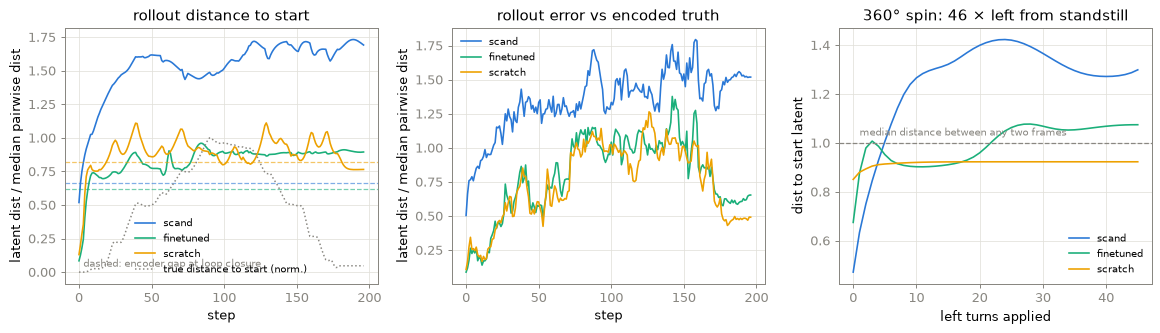

In [8]:
run1_all = {m: load_run(m, "data/spot_run1", 0.0, split="train")
            for m in ("scand", "finetuned", "scratch") if (ROOT / MODELS[m]["checkpoint"]).exists()}

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 3.8))
for name, r in run1_all.items():
    z_seq = torch.cat([r["z_t"], r["z_tp1"][-1:]])
    with torch.no_grad():
        z = z_seq[0][None]
        d_start, d_truth = [], []
        for row in range(len(r["ds"])):
            z = r["model"].predictor(z, r["ds"].actions[row][None])
            d_start.append((z[0] - z_seq[0]).norm().item())
            d_truth.append((z[0] - z_seq[row + 1]).norm().item())
    scale = torch.cdist(z_seq[::4], z_seq[::4]).median().item()  # typical latent distance
    ax1.plot(np.array(d_start) / scale, color=MODEL_COLORS[name], lw=1.3, label=name)
    ax2.plot(np.array(d_truth) / scale, color=MODEL_COLORS[name], lw=1.3, label=name)
    # encoder-level loop closure: same normalization as the rollout curve
    enc_gap = (z_seq[-1] - z_seq[0]).norm().item() / scale
    ax1.axhline(enc_gap, color=MODEL_COLORS[name], lw=1, ls="--", alpha=0.6)
r0 = next(iter(run1_all.values()))
true_d = np.hypot(*(r0["pos"] - r0["pos"][0]).T)
ax1.plot(true_d / true_d.max(), color=MUTED, lw=1.2, ls=":",
         label="true distance to start (norm.)")
ax1.text(3, 0.04, "dashed: encoder gap at loop closure", color=MUTED, fontsize=8)
ax1.set_title("rollout distance to start")
ax2.set_title("rollout error vs encoded truth")
for ax in (ax1, ax2):
    ax.set_xlabel("step"); ax.set_ylabel("latent dist / median pairwise dist")
    ax.legend(frameon=False, fontsize=8)

# 360-degree spin test from a standing frame
spin_n = int(round(360 / 7.8))
for name, r in run1_all.items():
    stops = np.flatnonzero(r["act"] == ACTIONS.index("stop"))
    start = int(stops[len(stops) // 2]) if len(stops) else 0
    with torch.no_grad():
        z0 = r["z_t"][start][None]
        z = z0.clone()
        d = []
        left = torch.eye(4)[ACTIONS.index("left")][None]
        for _ in range(spin_n):
            z = r["model"].predictor(z, left)
            d.append((z - z0).norm().item())
    z_seq = torch.cat([r["z_t"], r["z_tp1"][-1:]])
    scale = torch.cdist(z_seq[::4], z_seq[::4]).median().item()
    ax3.plot(np.array(d) / scale, color=MODEL_COLORS[name], lw=1.3, label=name)
ax3.axhline(1.0, color=MUTED, ls="--", lw=1)
ax3.text(1, 1.03, "median distance between any two frames", color=MUTED, fontsize=8)
ax3.set_title(f"360° spin: {spin_n} × left from standstill")
ax3.set_xlabel("left turns applied"); ax3.set_ylabel("dist to start latent")
ax3.legend(frameon=False, fontsize=8)
plt.tight_layout()

## 8. Planning in the model's imagination

Goal-conditioned planning is the world model's raison d'être: encode a start
frame and a goal frame from *h* steps later, enumerate **all 4^h action
sequences**, roll each through the predictor, and pick the sequence whose
imagined final latent lands closest to the goal.

Honest caveat: without a simulator we cannot *execute* the plan, so
everything is scored inside the model's imagination. Two grounded readouts
still work:

- **first-action agreement**: does the plan's first action match what the
  operator actually did? (compare against the majority-action rate)
- **plan vs executed, imagined**: rolling the *operator's own actions*
  through the predictor should land near the goal too; if random sequences
  do just as well, latent distance carries no action information.

,eval,horizon,first-action agreement,majority rate,imagined dist: plan,imagined dist: executed,imagined dist: random
0,zero-shot → run1,2,0.150,0.543,0.369,0.396,0.408
1,zero-shot → run1,4,0.200,0.543,0.556,0.633,0.649
2,finetuned → run1,2,0.250,0.543,1.945,2.005,2.027
3,finetuned → run1,4,0.300,0.543,2.544,2.673,2.726
4,scratch → run1,2,0.325,0.543,1.830,1.907,1.898
5,scratch → run1,4,0.325,0.543,1.897,2.007,2.004


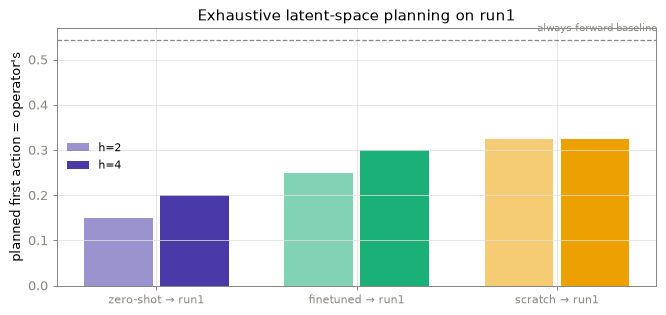

In [9]:
rng = np.random.default_rng(0)

@torch.no_grad()
def plan(r, s, h):
    seqs = torch.tensor(list(itertools.product(range(4), repeat=h)))
    z = r["z_t"][s][None].expand(len(seqs), -1)
    for j in range(h):
        z = r["model"].predictor(z, torch.eye(4)[seqs[:, j]])
    d = (z - r["z_t"][s + h][None]).square().mean(1)
    return seqs, d

rows = []
for label in run1_labels:
    r = runs[label]
    for h in (2, 4):
        agree, d_plan, d_exec, d_rand = [], [], [], []
        starts = [s for seg in r["segs"] for s in seg[:-h:3]]
        for s in rng.permutation(starts)[:40]:
            seqs, d = plan(r, int(s), h)
            best = d.argmin()
            executed = r["act"][s:s + h]
            agree.append(int(seqs[best, 0]) == executed[0])
            d_plan.append(d[best].item())
            d_exec.append(d[(seqs == torch.tensor(executed)).all(1)].item())
            d_rand.append(d[rng.integers(len(d))].item())
        maj = np.bincount(r["act"], minlength=4).max() / len(r["act"])
        rows.append({"eval": label, "horizon": h,
                     "first-action agreement": np.mean(agree), "majority rate": maj,
                     "imagined dist: plan": np.mean(d_plan),
                     "imagined dist: executed": np.mean(d_exec),
                     "imagined dist: random": np.mean(d_rand)})
plans = pd.DataFrame(rows).round(3)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
w, x = 0.38, np.arange(len(run1_labels))
for k, h in enumerate((2, 4)):
    sub = plans[plans["horizon"] == h].set_index("eval").loc[run1_labels]
    ax.bar(x + (k - 0.5) * w, sub["first-action agreement"], w * 0.9,
           color=[EVAL_COLORS[l] for l in run1_labels], alpha=1.0 if k else 0.55,
           label=f"h={h}")
ax.axhline(plans["majority rate"].iloc[0], color=MUTED, ls="--", lw=1)
ax.text(len(x) - 0.5, plans["majority rate"].iloc[0] + 0.02, "always-forward baseline",
        color=MUTED, fontsize=8, ha="right")
ax.set_xticks(x, run1_labels, fontsize=9)
ax.set_ylabel("planned first action = operator's")
ax.set_title("Exhaustive latent-space planning on run1")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plans

## 9. Verdict

Auto-generated summary: ✅ criterion met · ⚠️ partially · ❌ not met.

In [10]:
def flag(ok, warn=None):
    return "✅" if ok else ("⚠️" if warn else "❌")

verdict = []
for label, r in runs.items():
    z = torch.cat([r["z_t"], r["z_tp1"]])
    c = collapse_metrics(z)
    mse = (r["z_pred"] - r["z_tp1"]).square().mean(1).numpy()
    pers = (r["z_t"] - r["z_tp1"]).square().mean(1).numpy()
    rel = mse.mean() / pers.mean()
    err, base = rollout_curve(r, 6)
    pr = probes.loc[label]
    bb_key = f"DINOv2 backbone ({'run1' if 'run1' in label else 'scand'})"
    bb = probes.loc[bb_key] if bb_key in probes.index else pr
    verdict.append({
        "eval": label,
        "no collapse": flag(0.3 < c["per_dim_std"] < 3 and c["effective_rank"] > 8
                            and abs(c["mean_pairwise_cosine"]) < 0.4),
        "position decodable": flag(pr["pos R² (z)"] > 0.5, pr["pos R² (z)"] > 0.2),
        "heading decodable": flag(pr["heading R² (z)"] > 0.5, pr["heading R² (z)"] > 0.2),
        "head kept backbone info": flag(pr["pos R² (z)"] > 0.8 * max(bb["pos R² (z)"], 1e-6),
                                        pr["pos R² (z)"] > 0.5 * max(bb["pos R² (z)"], 1e-6)),
        "action visible in Δz": flag(pr["action acc (Δz)"] > pr["majority"] + 0.15,
                                     pr["action acc (Δz)"] > pr["majority"] + 0.05),
        "beats persistence (1-step)": flag(rel < 1.0, rel < 1.5),
        "useful rollout horizon": flag((err / base < 1).any(), (err / base < 1.3).any()),
    })
verdict = pd.DataFrame(verdict).set_index("eval")
print(verdict.to_string())
verdict

                     no collapse position decodable heading decodable head kept backbone info action visible in Δz beats persistence (1-step) useful rollout horizon
eval                                                                                                                                                                
scand → SAC held-out           ✅                  ✅                 ✅                       ✅                    ❌                         ⚠️                     ⚠️
zero-shot → run1               ❌                  ✅                 ✅                       ✅                    ❌                          ❌                      ❌
finetuned → run1               ✅                  ✅                 ✅                       ✅                    ❌                          ❌                      ❌
scratch → run1                 ✅                  ✅                 ✅                       ✅                    ❌                          ❌                      ❌


,no collapse,position decodable,heading decodable,head kept backbone info,action visible in Δz,beats persistence (1-step),useful rollout horizon
eval,,,,,,,
scand → SAC held-out,✅,✅,✅,✅,❌,⚠️,⚠️
zero-shot → run1,❌,✅,✅,✅,❌,❌,❌
finetuned → run1,✅,✅,✅,✅,❌,❌,❌
scratch → run1,✅,✅,✅,✅,❌,❌,❌


## Reading list — where these evaluations come from

- **Linear probing & effective rank as SSL quality measures**:
  [LeJEPA paper](https://arxiv.org/html/2511.08544v3) (training loss tracks
  probe performance), [RankMe / LDReg](https://arxiv.org/pdf/2401.10474),
  [LiDAR probing metric](https://arxiv.org/pdf/2312.04000).
- **Probing latents for physical variables** (linear + MLP probes):
  [Probing the Latent World](https://arxiv.org/html/2603.20327v1).
- **Rollout-horizon and consistency evaluation for latent world models**:
  [Latent world models taxonomy & evaluation framework](https://arxiv.org/pdf/2603.09086),
  [Action-Consistency Transfer Matrix](https://arxiv.org/pdf/2606.09028).
- **Goal-conditioned latent planning**: LeWorldModel /
  [le-wm](https://github.com/lucas-maes/le-wm), whose planner scores action
  sequences by latent distance exactly as §8 does.

Notebook conventions: everything runs off the cached DINOv2 embeddings and
`transitions.csv` poses; contiguous probe splits avoid temporal leakage; all
rollouts respect trajectory/bag boundaries.